# Discount Impact Analysis

## Objective

This notebook analyses the relationship between discounting and financial performance within the APL Logistics dataset.

The analysis focuses on:

- Discount distribution across transactions
- Discount rate and profitability
- Profitability across discount bands
- High-discount transactions
- Discount exposure by product and category
- Discount exposure by customer
- Relationship between discounting and profit margin
- Discount Impact Ratio

The purpose is to identify patterns of potential margin erosion and areas where discounting may require further commercial investigation.

Discount-related relationships are interpreted descriptively. The analysis does not assume that discounting directly causes changes in profitability.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Load the Processed Dataset

DATA_PATH = "../data/processed/apl_logistics_eda.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (180519, 42)


,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Item Total,Order Profit Per Order,Order Region,Order State,Order Status,Product Name,Product Price,Shipping Mode,Profitability Status,Transaction Profit Margin
0,DEBIT,6,4,159.69,472.45,Late delivery,1,9,Cardio Equipment,Brownsville,...,472.45,159.69,South Asia,Maharashtra,COMPLETE,Nike Men's Free 5.0+ Running Shoe,99.99,Standard Class,Profitable,0.338004
1,DEBIT,4,4,48.71,167.96,Shipping on time,0,29,Shop By Sport,Littleton,...,167.96,48.71,Central America,CortÃ©s,ON_HOLD,Under Armour Girls' Toddler Spine Surge Runni,39.99,Standard Class,Profitable,0.290010
2,DEBIT,4,4,87.36,181.99,Shipping on time,0,48,Water Sports,Littleton,...,181.99,87.36,Central America,CortÃ©s,ON_HOLD,Pelican Sunstream 100 Kayak,199.99,Standard Class,Profitable,0.480026
3,DEBIT,6,4,-41.89,175.99,Late delivery,1,48,Water Sports,Littleton,...,175.99,-41.89,East of USA,Nueva York,COMPLETE,Pelican Sunstream 100 Kayak,199.99,Standard Class,Loss-making,-0.238025
4,DEBIT,6,4,10.00,40.00,Late delivery,1,24,Women's Apparel,Littleton,...,40.00,10.00,East of USA,Nueva York,COMPLETE,Nike Men's Dri-FIT Victory Golf Polo,50.00,Standard Class,Profitable,0.250000


In [17]:
# Load product profitability results from Notebook 04

PRODUCT_PATH = "../data/processed/product_profitability.csv"

product_profitability = pd.read_csv(PRODUCT_PATH)

print("Product profitability shape:", product_profitability.shape)

product_profitability.head()

Product profitability shape: (118, 11)


,Product Name,Category,Department,Orders,Units,Sales,Profit,Discount,Avg_Discount_Rate,Avg_Product_Price,Profit_Margin
0,Adult dog supplies,Pet Supplies,Pet Shop,492,492,41524.80,3589.26,4206.50,0.101585,84.40,0.086437
1,Baby sweater,Baby,Apparel,207,207,12229.56,1525.03,1272.16,0.104300,59.08,0.124700
2,Bag Boy Beverage Holder,Golf Gloves,Outdoors,279,845,21116.55,3173.78,2106.64,0.099785,24.99,0.150298
3,Bag Boy M330 Push Cart,Golf Gloves,Outdoors,69,208,16637.92,2969.11,1656.26,0.103623,79.99,0.178454
4,Bowflex SelectTech 1090 Dumbbells,Fitness Accessories,Footwear,10,10,5999.90,1190.78,828.00,0.138000,599.99,0.198467


In [18]:
product_profitability.columns.tolist()

['Product Name',
 'Category',
 'Department',
 'Orders',
 'Units',
 'Sales',
 'Profit',
 'Discount',
 'Avg_Discount_Rate',
 'Avg_Product_Price',
 'Profit_Margin']

In [22]:
# Load category profitability results from Notebook 04

CATEGORY_PATH = "../data/processed/category_profitability.csv"

category_profitability = pd.read_csv(CATEGORY_PATH)

print("Category profitability shape:", category_profitability.shape)

category_profitability.head()

Category profitability shape: (50, 9)


,Category Name,Products,Orders,Units,Sales,Profit,Discount,Avg_Discount_Rate,Profit_Margin
0,Accessories,6,1780,5349,133671.51,16643.52,13959.32,0.103831,0.124511
1,As Seen on TV!,1,68,206,20597.94,714.43,2078.37,0.109412,0.034685
2,Baby,1,207,207,12229.56,1525.03,1272.16,0.104300,0.124700
3,Baseball & Softball,3,632,1785,94057.15,12762.13,9689.99,0.102943,0.135685
4,Basketball,3,67,67,27099.33,1845.67,2394.00,0.098955,0.068108


In [3]:
# Check discount fields 

discount_columns = [
    "Order Item Discount",
    "Order Item Discount Rate",
    "Sales",
    "Order Item Total",
    "Order Profit Per Order"
]

df[discount_columns].describe()

,Order Item Discount,Order Item Discount Rate,Sales,Order Item Total,Order Profit Per Order
count,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000
mean,20.664741,0.101668,203.772092,183.107607,21.974989
std,21.800901,0.070415,132.273075,120.043668,104.433526
min,0.000000,0.000000,9.990000,7.490000,-4274.980000
25%,5.400000,0.040000,119.980000,104.380000,7.000000
50%,14.000000,0.100000,199.920000,163.990000,31.520000
75%,29.990000,0.160000,299.950000,247.400000,64.800000
max,500.000000,0.250000,1999.990000,1939.990000,911.800000


In [4]:
# Validat discount rate

df["Calculated_Discount_Rate"] = (
    df["Order Item Discount"] / df["Sales"]
)

discount_rate_difference = (
    df["Calculated_Discount_Rate"]
    - df["Order Item Discount Rate"]
).abs()

print(
    "Maximum discount-rate difference:",
    discount_rate_difference.max()
)

print(
    "Records with difference > 0.01:",
    (discount_rate_difference > 0.01).sum()
)

Maximum discount-rate difference: 0.005407279029462732
Records with difference > 0.01: 0


In [5]:
# Basic discount statistics

discount_summary = pd.DataFrame({
    "Metric": [
        "Total Discount",
        "Average Discount",
        "Median Discount",
        "Maximum Discount",
        "Average Discount Rate",
        "Median Discount Rate",
        "Maximum Discount Rate"
    ],
    "Value": [
        df["Order Item Discount"].sum(),
        df["Order Item Discount"].mean(),
        df["Order Item Discount"].median(),
        df["Order Item Discount"].max(),
        df["Order Item Discount Rate"].mean(),
        df["Order Item Discount Rate"].median(),
        df["Order Item Discount Rate"].max()
    ]
})

discount_summary

,Metric,Value
0,Total Discount,3.730378e+06
1,Average Discount,2.066474e+01
2,Median Discount,1.400000e+01
3,Maximum Discount,5.000000e+02
4,Average Discount Rate,1.016682e-01
5,Median Discount Rate,1.000000e-01
6,Maximum Discount Rate,2.500000e-01


In [6]:
print(
    f"Average discount rate: "
    f"{df['Order Item Discount Rate'].mean() * 100:.2f}%"
)

print(
    f"Median discount rate: "
    f"{df['Order Item Discount Rate'].median() * 100:.2f}%"
)

print(
    f"Maximum discount rate: "
    f"{df['Order Item Discount Rate'].max() * 100:.2f}%"
)

Average discount rate: 10.17%
Median discount rate: 10.00%
Maximum discount rate: 25.00%


In [8]:
# Create Discount Bands

discount_bins = [-0.001, 0, 0.05, 0.10, 0.15, 0.20, 0.25]
discount_labels = [
    "No Discount",
    "Low (0-5%)",
    "Moderate (5-10%)",
    "High (10-15%)",
    "Very High (15-20%)",
    "Highest (20-25%)"
]

df["Discount_Band"] = pd.cut(
    df["Order Item Discount Rate"],
    bins=discount_bins,
    labels=discount_labels,
    include_lowest=True
)

df["Discount_Band"].value_counts().sort_index()

Discount_Band
No Discount           10028
Low (0-5%)            50143
Moderate (5-10%)      40116
High (10-15%)         30087
Very High (15-20%)    40116
Highest (20-25%)      10029
Name: count, dtype: int64

In [9]:
# Profitability by discount band

discount_band_analysis = (
    df.groupby("Discount_Band", observed=False)
      .agg(
          Transactions=("Order Item Discount Rate", "count"),
          Sales=("Sales", "sum"),
          Discount=("Order Item Discount", "sum"),
          Profit=("Order Profit Per Order", "sum")
      )
      .reset_index()
)

discount_band_analysis["Profit_Margin"] = (
    discount_band_analysis["Profit"] /
    discount_band_analysis["Sales"]
)

discount_band_analysis["Discount_as_Sales"] = (
    discount_band_analysis["Discount"] /
    discount_band_analysis["Sales"]
)

discount_band_analysis

,Discount_Band,Transactions,Sales,Discount,Profit,Profit_Margin,Discount_as_Sales
0,No Discount,10028,2042369.14,0.00,267412.40,0.130932,0.000000
1,Low (0-5%),50143,10215745.61,306523.06,1171682.08,0.114694,0.030005
2,Moderate (5-10%),40116,8173852.12,643742.60,926511.63,0.113351,0.078756
3,High (10-15%),30087,6131787.37,817610.24,625339.12,0.101983,0.133340
4,Very High (15-20%),40116,8176657.73,1451398.93,784061.02,0.095890,0.177505
5,Highest (20-25%),10029,2044322.34,511103.57,191896.72,0.093868,0.250011


In [10]:
# Add transaction share

discount_band_analysis["Transaction_Share"] = (
    discount_band_analysis["Transactions"] /
    discount_band_analysis["Transactions"].sum()
)

discount_band_display = discount_band_analysis.copy()

discount_band_display["Transaction_Share"] = (
    discount_band_display["Transaction_Share"] * 100
).round(2)

discount_band_display["Profit_Margin"] = (
    discount_band_display["Profit_Margin"] * 100
).round(2)

discount_band_display["Discount_as_Sales"] = (
    discount_band_display["Discount_as_Sales"] * 100
).round(2)

discount_band_display

,Discount_Band,Transactions,Sales,Discount,Profit,Profit_Margin,Discount_as_Sales,Transaction_Share
0,No Discount,10028,2042369.14,0.00,267412.40,13.09,0.00,5.56
1,Low (0-5%),50143,10215745.61,306523.06,1171682.08,11.47,3.00,27.78
2,Moderate (5-10%),40116,8173852.12,643742.60,926511.63,11.34,7.88,22.22
3,High (10-15%),30087,6131787.37,817610.24,625339.12,10.20,13.33,16.67
4,Very High (15-20%),40116,8176657.73,1451398.93,784061.02,9.59,17.75,22.22
5,Highest (20-25%),10029,2044322.34,511103.57,191896.72,9.39,25.00,5.56


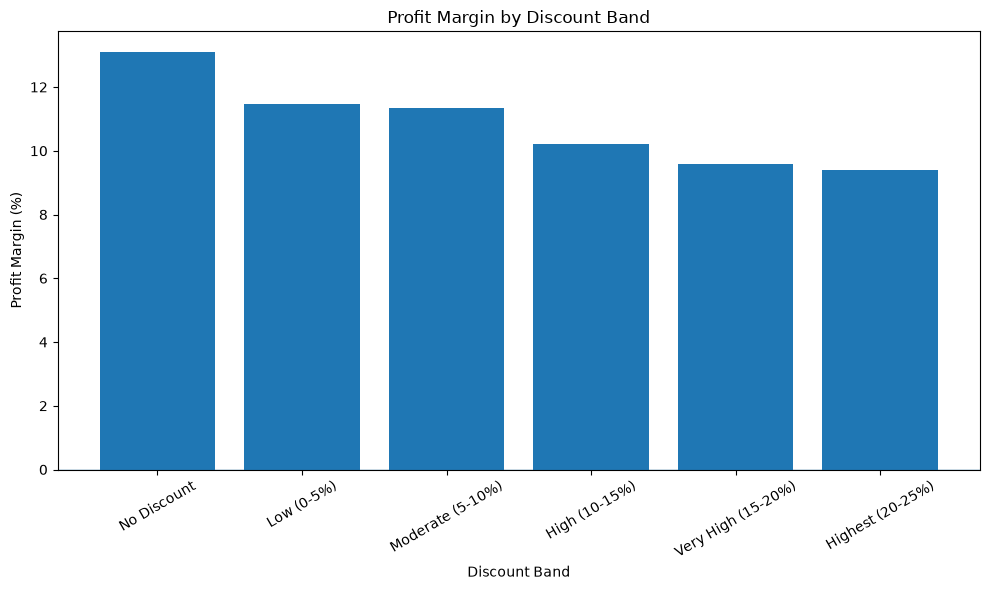

In [11]:
# Profit margin by discount band

plt.figure(figsize=(10, 6))

plt.bar(
    discount_band_analysis["Discount_Band"].astype(str),
    discount_band_analysis["Profit_Margin"] * 100
)

plt.axhline(0, linewidth=1)

plt.title("Profit Margin by Discount Band")
plt.xlabel("Discount Band")
plt.ylabel("Profit Margin (%)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [12]:
# Quantify the margin difference 

no_discount_margin = discount_band_analysis.loc[
    discount_band_analysis["Discount_Band"] == "No Discount",
    "Profit_Margin"
].iloc[0]

highest_discount_margin = discount_band_analysis.loc[
    discount_band_analysis["Discount_Band"] == "Highest (20-25%)",
    "Profit_Margin"
].iloc[0]

margin_difference = no_discount_margin - highest_discount_margin

print(f"No-discount profit margin: {no_discount_margin * 100:.2f}%")
print(f"Highest-discount profit margin: {highest_discount_margin * 100:.2f}%")
print(f"Margin difference: {margin_difference * 100:.2f} percentage points")

No-discount profit margin: 13.09%
Highest-discount profit margin: 9.39%
Margin difference: 3.71 percentage points


In [13]:
# Discount rate vs profit margin correlation

discount_margin_correlation = df[
    ["Order Item Discount Rate", "Transaction Profit Margin"]
].corr()

discount_margin_correlation

,Order Item Discount Rate,Transaction Profit Margin
Order Item Discount Rate,1.000000,-0.002701
Transaction Profit Margin,-0.002701,1.000000


In [14]:
correlation_value = discount_margin_correlation.loc[
    "Order Item Discount Rate",
    "Transaction Profit Margin"
]

print(
    f"Discount rate vs profit margin correlation: "
    f"{correlation_value:.4f}"
)

Discount rate vs profit margin correlation: -0.0027


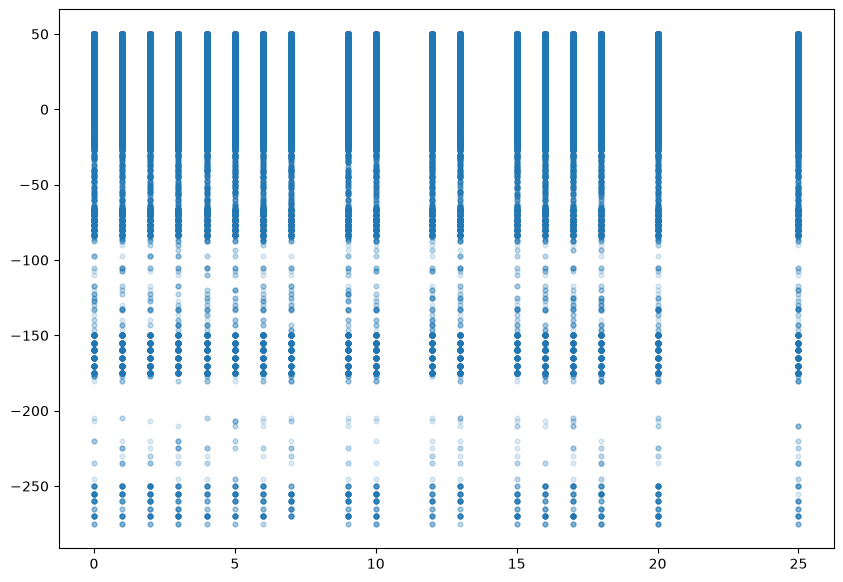

In [15]:
# Discoutn rate vs profit margin scatter plot

plt.figure(figsize=(10,7))

plt.scatter(
    df["Order Item Discount Rate"] * 100,
    df["Transaction Profit Margin"] * 100,
    alpha=0.15,
    s=12
)

In [16]:
# Discount impact ratio 

total_discount = df["Order Item Discount"].sum()
total_sales = df["Sales"].sum()

discount_impact_ratio = total_discount / total_sales

print(
    f"Discount Impact Ratio: "
    f"{discount_impact_ratio:.4f}"
)

print(
    f"Discount Impact Ratio: "
    f"{discount_impact_ratio * 100:.2f}%"
)

Discount Impact Ratio: 0.1014
Discount Impact Ratio: 10.14%


In [19]:
# Move from transaction to products

product_discount_analysis = product_profitability.copy()

product_discount_analysis["Discount_as_Sales"] = (
    product_discount_analysis["Discount"] /
    product_discount_analysis["Sales"]
)

product_discount_analysis[
    [
        "Product Name",
        "Category",
        "Sales",
        "Profit",
        "Profit_Margin",
        "Discount",
        "Avg_Discount_Rate",
        "Discount_as_Sales"
    ]
].sort_values(
    "Discount",
    ascending=False
).head(15)

,Product Name,Category,Sales,Profit,Profit_Margin,Discount,Avg_Discount_Rate,Discount_as_Sales
24,Field & Stream Sportsman 16 Gun Fire Safe,Fishing,6929653.50,756220.76,0.109128,702728.00,0.101681,0.101409
71,Perfect Fitness Perfect Rip Deck,Cleats,4421143.02,493828.30,0.111697,447968.17,0.101590,0.101324
21,Diamondback Women's Serene Classic Comfort Bi,Camping & Hiking,4118425.42,427455.57,0.103791,417649.50,0.101681,0.101410
61,Nike Men's Free 5.0+ Running Shoe,Cardio Equipment,3667633.20,379915.82,0.103586,371942.59,0.101695,0.101412
59,Nike Men's Dri-FIT Victory Golf Polo,Women's Apparel,3147800.00,350421.03,0.111323,319091.50,0.101669,0.101370
70,Pelican Sunstream 100 Kayak,Water Sports,3099845.00,324076.37,0.104546,314327.00,0.101674,0.101401
56,Nike Men's CJ Elite 2 TD Football Cleat,Men's Footwear,2891757.54,311902.82,0.107859,293263.10,0.101683,0.101413
67,O'Brien Men's Neoprene Life Vest,Indoor/Outdoor Games,2888993.94,318451.43,0.110229,292550.63,0.101493,0.101264
102,Under Armour Girls' Toddler Spine Surge Runni,Shop By Sport,1269082.65,126278.51,0.099504,128314.03,0.101411,0.101108
18,Dell Laptop,Computers,663000.00,69656.81,0.105063,67605.00,0.102240,0.101968


In [20]:
# Products with highest discount rates

product_discount_rate = product_profitability[
    [
        "Product Name",
        "Category",
        "Sales",
        "Profit",
        "Profit_Margin",
        "Discount",
        "Avg_Discount_Rate"
    ]
].sort_values(
    "Avg_Discount_Rate",
    ascending=False
)

product_discount_rate.head(15)

,Product Name,Category,Sales,Profit,Profit_Margin,Discount,Avg_Discount_Rate
4,Bowflex SelectTech 1090 Dumbbells,Fitness Accessories,5999.90,1190.78,0.198467,828.00,0.138000
77,SOLE E35 Elliptical,Strength Training,29999.85,-965.12,-0.032171,3590.00,0.120000
19,Diamondback Boys' Insight 24 Performance Hybr,Basketball,8699.71,1730.81,0.198950,1033.50,0.118966
45,LIJA Women's Mid-Length Panel Golf Shorts,Golf Shoes,22700.00,2984.71,0.131485,2568.00,0.116438
8,Brooks Women's Ghost 6 Running Shoe,Boxing & MMA,19077.88,2606.85,0.136643,2108.98,0.114697
42,LIJA Women's Argyle Golf Polo,Golf Shoes,15600.00,1512.43,0.096951,1749.20,0.113333
92,The North Face Women's Recon Backpack,Hunting & Shooting,17919.00,2803.80,0.156471,1927.54,0.111404
27,Fitbit The One Wireless Activity & Sleep Trac,Kids' Golf Clubs,18690.65,2088.02,0.111715,1931.56,0.110806
117,insta-bed Neverflat Air Mattress,Hunting & Shooting,8999.40,1036.62,0.115188,987.75,0.110000
62,Nike Men's Free TR 5.0 TB Training Shoe,As Seen on TV!,20597.94,714.43,0.034685,2078.37,0.109412


In [21]:
# High discount + low margin products

product_discount_median = (
    product_profitability["Avg_Discount_Rate"].median()
)

product_margin_median = (
    product_profitability["Profit_Margin"].median()
)

high_discount_low_margin_products = product_profitability[
    (product_profitability["Avg_Discount_Rate"] >= product_discount_median) &
    (product_profitability["Profit_Margin"] < product_margin_median)
].copy()

print(
    f"High-discount / low-margin products: "
    f"{len(high_discount_low_margin_products)}"
)

high_discount_low_margin_products[
    [
        "Product Name",
        "Category",
        "Sales",
        "Profit",
        "Profit_Margin",
        "Discount",
        "Avg_Discount_Rate"
    ]
].sort_values(
    "Sales",
    ascending=False
)

High-discount / low-margin products: 28


,Product Name,Category,Sales,Profit,Profit_Margin,Discount,Avg_Discount_Rate
61,Nike Men's Free 5.0+ Running Shoe,Cardio Equipment,3667633.20,379915.82,0.103586,371942.59,0.101695
56,Nike Men's CJ Elite 2 TD Football Cleat,Men's Footwear,2891757.54,311902.82,0.107859,293263.10,0.101683
18,Dell Laptop,Computers,663000.00,69656.81,0.105063,67605.00,0.102240
78,Smart watch,Sporting Goods,117006.75,12518.61,0.106990,11943.73,0.102353
17,DVDs,DVDs,79395.54,6655.43,0.083826,8076.43,0.101988
44,LIJA Women's Eyelet Sleeveless Golf Polo,Golf Shoes,61490.00,6752.33,0.109812,6332.02,0.102071
48,Men's gala suit,Men's Clothing,43856.80,2006.04,0.045741,4491.21,0.102692
105,Under Armour Men's Compression EV SL Slide,Electronics,36576.87,3745.34,0.102396,3831.73,0.102714
82,TYR Boys' Team Digi Jammer,Girls' Apparel,35191.20,3658.98,0.103974,3754.54,0.106733
15,Clicgear Rovic Cooler Bag,Golf Gloves,34671.33,2962.96,0.085459,3638.95,0.104789


In [23]:
# Validate category data

category_profitability[
    [
        "Category Name",
        "Sales",
        "Profit",
        "Profit_Margin",
        "Discount",
        "Avg_Discount_Rate"
    ]
].head(10)

,Category Name,Sales,Profit,Profit_Margin,Discount,Avg_Discount_Rate
0,Accessories,133671.51,16643.52,0.124511,13959.32,0.103831
1,As Seen on TV!,20597.94,714.43,0.034685,2078.37,0.109412
2,Baby,12229.56,1525.03,0.124700,1272.16,0.104300
3,Baseball & Softball,94057.15,12762.13,0.135685,9689.99,0.102943
4,Basketball,27099.33,1845.67,0.068108,2394.00,0.098955
5,Books,12587.40,883.01,0.070150,1283.98,0.102296
6,Boxing & MMA,85205.41,8641.37,0.101418,8918.79,0.103664
7,CDs,3059.59,383.85,0.125458,309.56,0.101476
8,Cameras,267607.68,30289.80,0.113187,27111.00,0.101588
9,Camping & Hiking,4118425.42,427455.57,0.103791,417649.50,0.101681


In [25]:
# Discount exposure by category

category_discount_analysis = category_profitability.copy()

category_discount_analysis["Discount_as_Sales"] = (
    category_discount_analysis["Discount"] /
    category_discount_analysis["Sales"]
)

category_discount_analysis[
    [
        "Category Name",
        "Products",
        "Sales",
        "Profit",
        "Profit_Margin",
        "Discount",
        "Avg_Discount_Rate",
        "Discount_as_Sales"
    ]
].sort_values(
    "Discount",
    ascending=False
).head(15)

,Category Name,Products,Sales,Profit,Profit_Margin,Discount,Avg_Discount_Rate,Discount_as_Sales
18,Fishing,1,6929653.50,756220.76,0.109128,702728.00,0.101681,0.101409
12,Cleats,2,4431942.66,494636.92,0.111607,449091.67,0.101594,0.101331
9,Camping & Hiking,1,4118425.42,427455.57,0.103791,417649.50,0.101681,0.101410
10,Cardio Equipment,2,3694843.20,383011.10,0.103661,374595.19,0.101651,0.101383
47,Women's Apparel,1,3147800.00,350421.03,0.111323,319091.50,0.101669,0.101370
46,Water Sports,2,3113844.60,325146.96,0.104420,315800.50,0.101683,0.101418
34,Men's Footwear,1,2891757.54,311902.82,0.107859,293263.10,0.101683,0.101413
30,Indoor/Outdoor Games,1,2888993.94,318451.43,0.110229,292550.63,0.101493,0.101264
38,Shop By Sport,3,1309522.02,129813.96,0.099131,132338.73,0.101362,0.101059
13,Computers,1,663000.00,69656.81,0.105063,67605.00,0.102240,0.101968


In [26]:
# Categories with highest discount rates

category_discount_rate = category_profitability[
    [
        "Category Name",
        "Products",
        "Sales",
        "Profit",
        "Profit_Margin",
        "Discount",
        "Avg_Discount_Rate"
    ]
].sort_values(
    "Avg_Discount_Rate",
    ascending=False
)

category_discount_rate.head(15)

,Category Name,Products,Sales,Profit,Profit_Margin,Discount,Avg_Discount_Rate
1,As Seen on TV!,1,20597.94,714.43,0.034685,2078.37,0.109412
26,Golf Shoes,4,107998.00,12406.07,0.114873,11491.62,0.105611
41,Strength Training,3,54895.53,332.31,0.006053,6081.72,0.105045
29,Hunting & Shooting,3,56848.42,5980.00,0.105192,5969.61,0.104705
2,Baby,1,12229.56,1525.03,0.124700,1272.16,0.104300
0,Accessories,6,133671.51,16643.52,0.124511,13959.32,0.103831
6,Boxing & MMA,3,85205.41,8641.37,0.101418,8918.79,0.103664
3,Baseball & Softball,3,94057.15,12762.13,0.135685,9689.99,0.102943
33,Men's Clothing,1,43856.80,2006.04,0.045741,4491.21,0.102692
19,Fitness Accessories,2,35601.44,5258.39,0.147702,3850.16,0.102589


In [27]:
# High discount + low margin categories

category_discount_median = (
    category_profitability["Avg_Discount_Rate"].median()
)

category_margin_median = (
    category_profitability["Profit_Margin"].median()
)

high_discount_low_margin_categories = category_profitability[
    (category_profitability["Avg_Discount_Rate"] >= category_discount_median) &
    (category_profitability["Profit_Margin"] < category_margin_median)
].copy()

print(
    f"High-discount / low-margin categories: "
    f"{len(high_discount_low_margin_categories)}"
)

high_discount_low_margin_categories[
    [
        "Category Name",
        "Products",
        "Sales",
        "Profit",
        "Profit_Margin",
        "Discount",
        "Avg_Discount_Rate"
    ]
].sort_values(
    "Sales",
    ascending=False
)

High-discount / low-margin categories: 13


,Category Name,Products,Sales,Profit,Profit_Margin,Discount,Avg_Discount_Rate
34,Men's Footwear,1,2891757.54,311902.82,0.107859,293263.10,0.101683
13,Computers,1,663000.00,69656.81,0.105063,67605.00,0.102240
17,Electronics,11,371034.64,40891.38,0.110209,37708.03,0.101838
40,Sporting Goods,1,117006.75,12518.61,0.106990,11943.73,0.102353
6,Boxing & MMA,3,85205.41,8641.37,0.101418,8918.79,0.103664
16,DVDs,1,79395.54,6655.43,0.083826,8076.43,0.101988
29,Hunting & Shooting,3,56848.42,5980.00,0.105192,5969.61,0.104705
41,Strength Training,3,54895.53,332.31,0.006053,6081.72,0.105045
33,Men's Clothing,1,43856.80,2006.04,0.045741,4491.21,0.102692
32,Lacrosse,2,39464.79,4364.29,0.110587,4048.94,0.102274


In [28]:
# Category discount rate vs profit margin 

category_discount_margin_correlation = (
    category_profitability[
        ["Avg_Discount_Rate", "Profit_Margin"]
    ].corr()
)

category_discount_margin_correlation

,Avg_Discount_Rate,Profit_Margin
Avg_Discount_Rate,1.00000,-0.45106
Profit_Margin,-0.45106,1.00000


In [29]:
category_correlation_value = (
    category_discount_margin_correlation.loc[
        "Avg_Discount_Rate",
        "Profit_Margin"
    ]
)

print(
    f"Category discount rate vs profit margin correlation: "
    f"{category_correlation_value:.4f}"
)

Category discount rate vs profit margin correlation: -0.4511


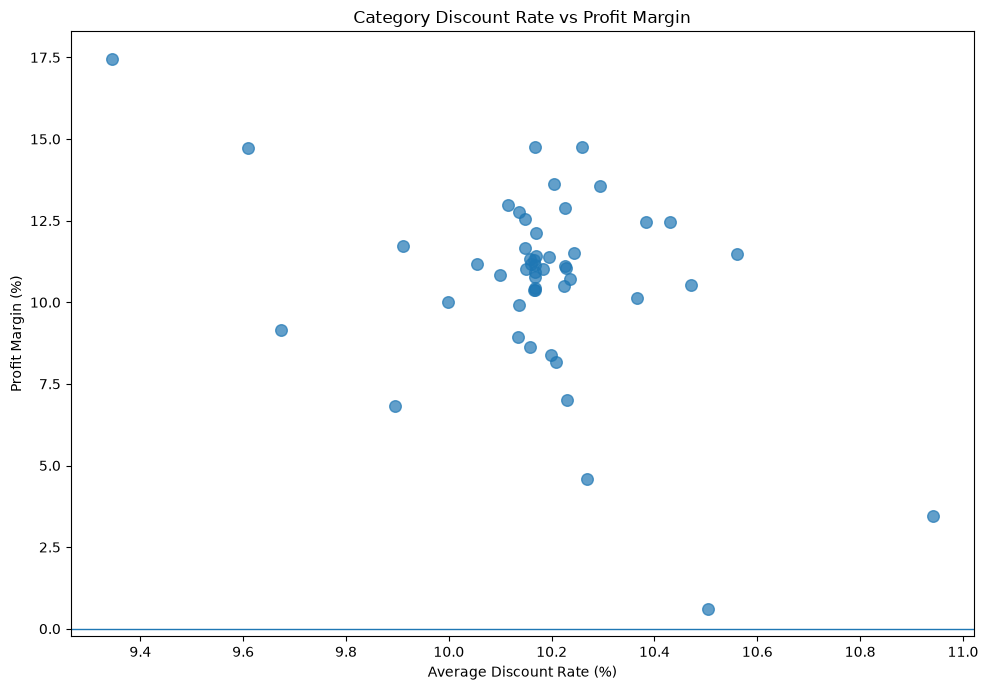

In [30]:
# Category discount rate vs profit margin

plt.figure(figsize=(10, 7))

plt.scatter(
    category_profitability["Avg_Discount_Rate"] * 100,
    category_profitability["Profit_Margin"] * 100,
    s=70,
    alpha=0.7
)

plt.axhline(0, linewidth=1)

plt.title("Category Discount Rate vs Profit Margin")
plt.xlabel("Average Discount Rate (%)")
plt.ylabel("Profit Margin (%)")

plt.tight_layout()
plt.show()

In [31]:
# Financial exposure of high-discount / low margin categories

high_discount_low_margin_category_summary = pd.DataFrame({
    "Categories": [
        len(high_discount_low_margin_categories)
    ],
    "Sales": [
        high_discount_low_margin_categories["Sales"].sum()
    ],
    "Profit": [
        high_discount_low_margin_categories["Profit"].sum()
    ],
    "Discount": [
        high_discount_low_margin_categories["Discount"].sum()
    ]
})

high_discount_low_margin_category_summary["Profit_Margin"] = (
    high_discount_low_margin_category_summary["Profit"] /
    high_discount_low_margin_category_summary["Sales"]
)

high_discount_low_margin_category_summary["Sales_Share"] = (
    high_discount_low_margin_category_summary["Sales"] /
    category_profitability["Sales"].sum()
)

high_discount_low_margin_category_summary

,Categories,Sales,Profit,Discount,Profit_Margin,Sales_Share
0,13,4468961.26,467264.02,454861.6,0.104558,0.12149


In [32]:
# Compare high-discount / low margin categories

print(
    f"High-discount / low-margin categories: "
    f"{len(high_discount_low_margin_categories)}"
)

print(
    f"Sales share: "
    f"{high_discount_low_margin_category_summary['Sales_Share'].iloc[0] * 100:.2f}%"
)

print(
    f"Combined profit margin: "
    f"{high_discount_low_margin_category_summary['Profit_Margin'].iloc[0] * 100:.2f}%"
)

print(
    f"Total discount exposure: "
    f"{high_discount_low_margin_category_summary['Discount'].iloc[0]:,.2f}"
)

High-discount / low-margin categories: 13
Sales share: 12.15%
Combined profit margin: 10.46%
Total discount exposure: 454,861.60


In [33]:
# Save the discount analysis outputs

high_discount_low_margin_products.to_csv(
    "../data/processed/high_discount_low_margin_products.csv",
    index=False
)

high_discount_low_margin_categories.to_csv(
    "../data/processed/high_discount_low_margin_categories.csv",
    index=False
)

discount_band_analysis.to_csv(
    "../data/processed/discount_band_analysis.csv",
    index=False
)

print("Discount analysis outputs saved successfully.")

Discount analysis outputs saved successfully.
